# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



Ray module not found. Multiprocessing features are not available


True

In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction/diffusion.txt"
).astype(
    int
)
# I create a list of the models
model_list=[0]*len(Discretizations)

In [4]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test=normalization(U_HF_test)
# transformation of the dataseet
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
# data augmentation introducing a noise
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

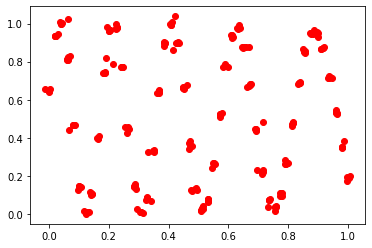

In [6]:
# plot of the new dataset
plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
plt.show()

In [7]:
#print(reaction_HF_test.shape)
#print(U_HF_test.shape)

# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([100])
Nlf = np.array([200])

batch_size=[200,100]


In [8]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7000,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

Folder '2_step_models' already exists.
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 42.012166261672974 seconds.


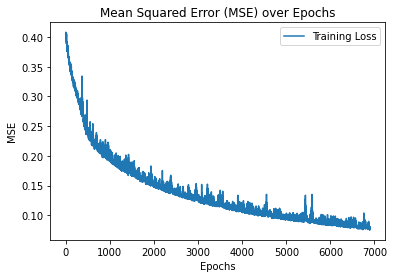

The function training took 34.270663261413574 seconds.


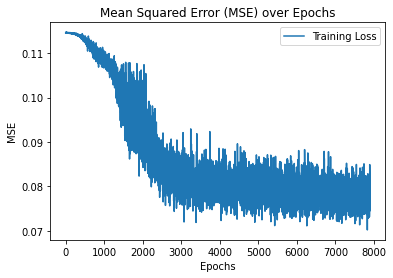

low fidelity NN
Test MSE: 0.005716675882208137
R^2: 0.9541132118663166
Final model
Test MSE: 0.09281654835663783
R^2: 0.18005704106456188


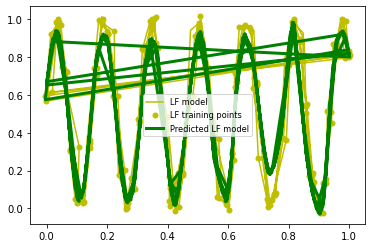

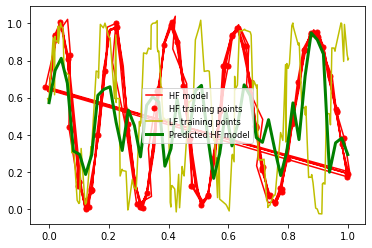

Saving ...
   Discretization  diffusion       R2
0            46.0        0.0  0.18006
   Discretization  diffusion      MSE
0            46.0        0.0  0.09282


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8176\4008916404.py:182: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8176\4008916404.py:184: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8176\4008916404.py:186: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8176\4008916404.py:188: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df.app

In [9]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
        
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )
                ### import of the Low Fidelity component of the dataset 
                file_path_LF = "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                # selection and normalization of the dataset
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                reaction_LF_test = normalization(reaction_LF_test)
                
                # transformation of the Low fidelity test set
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test
                
                # dataset augmentation adding a noise
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]
                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                
                # randomization and selection of the training set
                permutation = np.random.permutation(len(reaction_HF_test))
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                # transformation of the dataset
                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                ##########################      Neural Network     ##########################
                K.clear_session()
                
                # parameters 
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

                # reproducibilty porpuse 
                learning_rate = bestLF_params["lr"]
                optimizer_type = bestLF_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                
                
                # Multifidelity network 
                names=["LF","HF"]
                params=[bestLF_params, best_params]
                data_train=[reaction_LF, reaction_HF]
                output_train=[U_train_LF,U_HF]
                model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)
  
                # low fidelity part of the network 
                ULF = model.model_list[0].prediction(reaction_LF_test_original)
                print("low fidelity NN")
                
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                r2_LF_list.append(r2_LF)

                # creation of the input of the second part of the 2 steps NN to study the high fidelity model
                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 
                # performance of the last part of the network
                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
                test_mse_HF_list.append(test_mse_HF)
                r2_HF_list.append(r2_HF)
                
                
                # plots of the model
                plt.figure()
                plt.plot(
                reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
                )
                plt.plot(
                reaction_LF[:, 0],
                U_train_LF,
                "yo",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_LF_test[:, 0],
                model.model_list[0].prediction(reaction_LF_test),
                "g-",
                linewidth=3,
                label="Predicted LF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                plt.figure()
                plt.plot(
                reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                input_HF_train[:, 0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                input_HF[:, 0],
                model.model_list[1].prediction(input_HF),
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df = r2_LF_df.append(new, ignore_index=True)      
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df = r2_HF_df.append(new, ignore_index=True)  
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df = mse_LF_df.append(new, ignore_index=True) 
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df = mse_HF_df.append(new, ignore_index=True)
            
            
                # save the model
                if not r2_HF_list[:-1]:
                    model_list[m]=model
                    model.save(str(Discretizations[m]),folder_path)
                elif r2_HF_list[:-1] and r2_HF_list[-1] > max(r2_HF_list[:-1]):
                    model_list[m]=model
                    model.save(str(Discretizations[m]),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [10]:
os.makedirs(folder_path)

r2_HF_df.to_csv(
    "./{folder_name}/r2_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./{folder_name}/mse_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./{folder_name}/r2_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./{folder_name}/mse_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'c:\\Users\\Giacomo\\Desktop\\PACS_codice\\pacs_new\\PACS_project2\\Diffusion\\2_step_models'

# Inverse problem

In [11]:
dim=5
# before normalization I look for 5 values between 0.5 and 1.5
real_x = np.random.rand(dim)
reaction_HF_test_original=reaction_HF_test_original[:,0]
# I find the mmost similar value in our dataset, so that I can then find the "correct" U for the function
closest_indices = np.argmin(np.abs(reaction_HF_test_original[:, np.newaxis] - real_x), axis=0)
real_x=real_x.reshape(-1, 1)

nearest_x=reaction_HF_test_original[closest_indices]

In [12]:
# found the correct value, as if I have applied the real function
nearest_U=U_HF_test_original[closest_indices]
reaction_HF_test_original=np.c_[reaction_HF_test_original, np.abs(np.sin(5*np.pi*reaction_HF_test_original-5*np.pi/6))]

In [23]:
mean_prior = np.ones(dim)
cov_prior = np.ones(dim)*0.1*4  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1*4
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=4000#8000
burnin=2000#4000
n_chains=2

In [24]:
#real_x=np.c_[real_x, np.abs(np.sin(5*np.pi*real_x-5*np.pi/6))]
transformations= lambda x: np.abs(np.sin(5*np.pi*x-5*np.pi/6))
transformations=[transformations]

In [25]:
# from functools import reduce

# x_final = reduce(lambda acc, trasf: np.hstack([acc, trasf(acc)]), transformations, real_x)

In [26]:
nearest_U=nearest_U.reshape(-1,1)

In [27]:
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)

real values are [[0.46581281]
 [0.83599806]
 [0.23579209]
 [0.77600021]
 [0.40531018]]
Sampling chain 1/2


Running chain, α = 0.43:   5%|▌         | 203/4000 [00:38<11:52,  5.33it/s]


KeyboardInterrupt: 